# 06. Note Tier Ablation

## 1. 분석 목적

이번 분석의 핵심 질문은 다음과 같다.

> 같은 Note라도 Top / Middle / Base 중 어디에 위치하는지 구분하는 것이 단순히 Note 존재 여부만 사용하는 것보다 실제 향 유사성 추천에 추가적인 정보를 제공하는가?

비교의 공정성을 위해 다음 요소는 바꾸지 않는다.

- Accord: **Raw Accord Strength의 Cosine Similarity**
- Accord : Note 결합 비율: **0.5 : 0.5**
- Union Note: **IDF Weighted Jaccard**
- 평가 label: `reminds_me_of`에서 `total_votes >= 20`이고 `agree_ratio >= 0.8`인 pair

이번에 새로 검증하는 유일한 요소는 **Top / Middle / Base 위치 정보**이다. Season, Daypart, Community Gender, Longevity, Sillage, LLM, Embedding, 머신러닝 모델은 추가하지 않는다. `reminds_me_of`는 평가 label로만 쓰며 추천 점수에는 포함하지 않는다.

Development 700개 전체를 모델 개발 데이터로 사용하고 5-Fold Cross Validation으로 후보를 비교한다. Final Holdout 300개는 ID만 재현하며 추천 생성과 성능 평가에 절대 사용하지 않는다.

## 2. 환경 설정

In [1]:
import array
import collections
import gc
import json
import math
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy import sparse
from tqdm import tqdm

SEED = 42
N_FOLDS = 5
MAX_K = 20
BATCH_SIZE = 8
BOOTSTRAP_RESAMPLES = 2000
BETAS = np.round(np.arange(0.0, 1.01, 0.1), 1)
TIERS = ("top", "middle", "base")

jsonl_path = pathlib.Path.cwd() / "perfumes.jsonl"
assert jsonl_path.is_file(), f"파일을 찾을 수 없습니다: {jsonl_path}"
print(f"데이터: {jsonl_path.name} ({jsonl_path.stat().st_size / (1024 ** 2):,.2f} MB)")

데이터: perfumes.jsonl (485.94 MB)


## 3. 데이터 로드와 Note 구조 보존

Union Note용 이름 feature와 Tier Note용 `tier::note` feature를 동시에 만든다. flat Note는 임의의 tier로 변환하지 않는다.

Note 구조 분류 규칙:

1. `tiered`: top / middle / base 중 하나 이상 존재하고 flat은 없음
2. `flat`: flat이 존재하고 tiered는 없음
3. `no_notes`: 어느 쪽도 없음
4. `invalid`: tiered와 flat이 동시에 존재

In [2]:
perfume_ids = array.array("i")
perfume_names, perfume_brands = [], []
note_types = []
has_accord, has_note = array.array("b"), array.array("b")

accord_to_col = {}
accord_rows, accord_cols, accord_data = array.array("I"), array.array("I"), array.array("f")

note_to_col = {}
note_rows, note_cols = array.array("I"), array.array("I")

tier_token_to_col = {}
tier_rows, tier_cols = array.array("I"), array.array("I")

tier_note_rows = {tier: array.array("I") for tier in TIERS}
tier_note_cols = {tier: array.array("I") for tier in TIERS}

relation_source_ids, relation_target_ids = array.array("i"), array.array("i")
relation_up_votes, relation_down_votes = array.array("i"), array.array("i")

with jsonl_path.open("r", encoding="utf-8") as file:
    for line in tqdm(file, desc="JSONL load", unit=" perfumes"):
        if not line.strip():
            continue

        row_index = len(perfume_ids)
        record = json.loads(line)
        perfume_id = int(record["id"])
        perfume_ids.append(perfume_id)
        perfume_names.append(record.get("name") or "")
        perfume_brands.append(record.get("brand") or "")

        accord_strengths = {}
        for item in record.get("accords") or []:
            name, strength = item.get("name"), item.get("strength")
            if name and strength is not None:
                col = accord_to_col.setdefault(name, len(accord_to_col))
                accord_strengths[col] = float(strength)
        has_accord.append(bool(accord_strengths))
        for col, strength in accord_strengths.items():
            accord_rows.append(row_index)
            accord_cols.append(col)
            accord_data.append(strength)

        notes = record.get("notes") or {}
        tiered_block = notes.get("tiered") or {}
        names_by_tier = {
            tier: {item.get("name") for item in tiered_block.get(tier) or [] if item.get("name")}
            for tier in TIERS
        }
        flat_names = {item.get("name") for item in notes.get("flat") or [] if item.get("name")}
        has_tiered_values = any(names_by_tier[tier] for tier in TIERS)
        has_flat_values = bool(flat_names)

        if has_tiered_values and has_flat_values:
            note_type = "invalid"
        elif has_tiered_values:
            note_type = "tiered"
        elif has_flat_values:
            note_type = "flat"
        else:
            note_type = "no_notes"
        note_types.append(note_type)

        union_names = set(flat_names)
        for tier in TIERS:
            union_names.update(names_by_tier[tier])
        has_note.append(bool(union_names))

        for name in union_names:
            note_rows.append(row_index)
            note_cols.append(note_to_col.setdefault(name, len(note_to_col)))

        # Tier representation과 tier별 통계는 정상적인 tiered 향수만 사용한다.
        if note_type == "tiered":
            for tier in TIERS:
                for name in names_by_tier[tier]:
                    note_col = note_to_col.setdefault(name, len(note_to_col))
                    tier_note_rows[tier].append(row_index)
                    tier_note_cols[tier].append(note_col)
                    token = f"{tier}::{name}"
                    tier_rows.append(row_index)
                    tier_cols.append(tier_token_to_col.setdefault(token, len(tier_token_to_col)))

        for relation in (record.get("similar") or {}).get("reminds_me_of") or []:
            target_id = relation.get("id")
            up_votes, down_votes = relation.get("up_votes"), relation.get("down_votes")
            relation_source_ids.append(perfume_id)
            relation_target_ids.append(int(target_id) if target_id is not None else -1)
            relation_up_votes.append(int(up_votes) if up_votes is not None else -1)
            relation_down_votes.append(int(down_votes) if down_votes is not None else -1)

perfume_ids = np.asarray(perfume_ids, dtype=np.int32)
note_types = np.asarray(note_types, dtype="U8")
has_accord = np.asarray(has_accord, dtype=bool)
has_note = np.asarray(has_note, dtype=bool)
id_to_row = {int(perfume_id): row for row, perfume_id in enumerate(perfume_ids)}
n_perfumes = len(perfume_ids)

print(f"향수 수: {n_perfumes:,}")
print(f"고유 Accord 수: {len(accord_to_col):,}")
print(f"고유 Union Note 수: {len(note_to_col):,}")
print(f"고유 Tier Token 수: {len(tier_token_to_col):,}")
print(f"directed reminds_me_of 수: {len(relation_source_ids):,}")
assert len(accord_to_col) == 92, "04·05 Notebook의 92개 Accord 구조와 다릅니다."

JSONL load: 131930 perfumes [00:08, 15505.89 perfumes/s]


향수 수: 131,930
고유 Accord 수: 92
고유 Union Note 수: 2,523
고유 Tier Token 수: 5,446
directed reminds_me_of 수: 692,729


## 4. 04·05 Notebook 평가 데이터 재현

In [3]:
directed_relations = pd.DataFrame({
    "source_id": np.asarray(relation_source_ids, dtype=np.int32),
    "target_id": np.asarray(relation_target_ids, dtype=np.int32),
    "up_votes": np.asarray(relation_up_votes, dtype=np.int32),
    "down_votes": np.asarray(relation_down_votes, dtype=np.int32),
})
valid = directed_relations[
    (directed_relations["source_id"] > 0)
    & (directed_relations["target_id"] > 0)
    & (directed_relations["up_votes"] >= 0)
    & (directed_relations["down_votes"] >= 0)
].copy()
valid["pair_low"] = np.minimum(valid["source_id"], valid["target_id"])
valid["pair_high"] = np.maximum(valid["source_id"], valid["target_id"])
pair_relations = valid.groupby(["pair_low", "pair_high"], sort=False, as_index=False)[
    ["up_votes", "down_votes"]
].sum()
pair_relations["total_votes"] = pair_relations["up_votes"] + pair_relations["down_votes"]
pair_relations["agree_ratio"] = np.divide(
    pair_relations["up_votes"], pair_relations["total_votes"],
    out=np.full(len(pair_relations), np.nan),
    where=pair_relations["total_votes"].to_numpy() > 0,
)
relevant_pairs_all = pair_relations[
    (pair_relations["pair_low"] != pair_relations["pair_high"])
    & (pair_relations["total_votes"] >= 20)
    & (pair_relations["agree_ratio"] >= 0.8)
].copy()
inside_mask = (
    relevant_pairs_all["pair_low"].isin(id_to_row)
    & relevant_pairs_all["pair_high"].isin(id_to_row)
)
relevant_pairs = relevant_pairs_all.loc[inside_mask].copy()

relevant_by_query = collections.defaultdict(set)
for low, high in relevant_pairs[["pair_low", "pair_high"]].itertuples(index=False, name=None):
    low, high = int(low), int(high)
    relevant_by_query[low].add(high)
    relevant_by_query[high].add(low)

eligible_query_ids = np.array(sorted(
    query_id for query_id, items in relevant_by_query.items()
    if len(items) >= 2 and has_accord[id_to_row[query_id]] and has_note[id_to_row[query_id]]
), dtype=np.int32)

selection_rng = np.random.default_rng(SEED)
selected_query_ids = selection_rng.choice(eligible_query_ids, size=1000, replace=False)
split_rng = np.random.default_rng(SEED)
selected_query_ids = split_rng.permutation(selected_query_ids)
development_query_ids = selected_query_ids[:700]
final_holdout_query_ids = selected_query_ids[700:]

expected_development_head = [68393, 93820, 40155, 16220, 109598, 57684, 5634, 19669, 48389, 71291]
expected_holdout_head = [40468, 8894, 1658, 51250, 12112, 55166, 85084, 113714, 87451, 33253]
assert development_query_ids[:10].tolist() == expected_development_head
assert final_holdout_query_ids[:10].tolist() == expected_holdout_head
assert len(development_query_ids) == 700 and len(final_holdout_query_ids) == 300
assert set(development_query_ids).isdisjoint(final_holdout_query_ids)

reproduction_summary = pd.Series({
    "Relevant Pair 수": len(relevant_pairs_all),
    "평가 가능 Query 수": len(eligible_query_ids),
    "Development Query 수": len(development_query_ids),
    "Final Holdout Query 수": len(final_holdout_query_ids),
})
display(reproduction_summary.to_frame("값"))
print("Development Query ID 앞 10개:", development_query_ids[:10].tolist())
print("Holdout Query ID 앞 10개:", final_holdout_query_ids[:10].tolist())
print("05 Notebook과 동일한 split임을 앞 10개 ID 및 assert로 확인했습니다.")
print("Final Holdout은 이 셀 이후 어떤 추천/평가 함수에도 전달하지 않습니다.")

del directed_relations, valid, pair_relations
del relation_source_ids, relation_target_ids, relation_up_votes, relation_down_votes
gc.collect()

,값
Relevant Pair 수,10770
평가 가능 Query 수,3835
Development Query 수,700
Final Holdout Query 수,300


Development Query ID 앞 10개: [68393, 93820, 40155, 16220, 109598, 57684, 5634, 19669, 48389, 71291]
Holdout Query ID 앞 10개: [40468, 8894, 1658, 51250, 12112, 55166, 85084, 113714, 87451, 33253]
05 Notebook과 동일한 split임을 앞 10개 ID 및 assert로 확인했습니다.
Final Holdout은 이 셀 이후 어떤 추천/평가 함수에도 전달하지 않습니다.


40

## 5. Development 5-Fold 구성

`random seed=42`, `shuffle=True`와 같은 효과가 나도록 Development ID를 한 번 섞고 5개 fold로 나눈다. 이 retrieval 모델은 query로부터 feature similarity를 직접 계산하며 fold에서 학습되는 파라미터가 없다. 따라서 Development 700개의 랭킹을 한 번만 생성한 뒤 동일한 fold 구성을 사용해 모델별 지표를 집계한다. Fold별 평가 query는 서로 겹치지 않는다.

In [4]:
cv_rng = np.random.default_rng(SEED)
cv_permuted = cv_rng.permutation(development_query_ids)
cv_folds = [part.astype(np.int32, copy=False) for part in np.array_split(cv_permuted, N_FOLDS)]

assert [len(fold) for fold in cv_folds] == [140] * 5
assert len(set(np.concatenate(cv_folds))) == 700
assert set(np.concatenate(cv_folds)) == set(development_query_ids)
pd.DataFrame({"fold": np.arange(1, 6), "query_count": [len(fold) for fold in cv_folds]})

,fold,query_count
0,1,140
1,2,140
2,3,140
3,4,140
4,5,140


## 6. Note 구조 분석

In [5]:
def note_type_summary(rows, label):
    counts = pd.Series(note_types[rows]).value_counts().reindex(
        ["tiered", "flat", "no_notes", "invalid"], fill_value=0
    )
    return pd.DataFrame({
        "dataset": label,
        "note_type": counts.index,
        "count": counts.values,
        "ratio": counts.values / len(rows),
    })

all_rows = np.arange(n_perfumes, dtype=np.int32)
development_rows = np.array([id_to_row[int(q)] for q in development_query_ids], dtype=np.int32)
note_structure_df = pd.concat([
    note_type_summary(all_rows, "전체 향수"),
    note_type_summary(development_rows, "Development 700"),
], ignore_index=True)
display(note_structure_df.assign(ratio=lambda x: x["ratio"].map(lambda v: f"{v:.2%}")))

invalid_count = int((note_types == "invalid").sum())
print(f"invalid 향수 수: {invalid_count:,}")
print("flat Notes는 어떤 tier로도 변환하지 않았습니다.")

,dataset,note_type,count,ratio
0,전체 향수,tiered,93166,70.62%
1,전체 향수,flat,36222,27.46%
2,전체 향수,no_notes,2542,1.93%
3,전체 향수,invalid,0,0.00%
4,Development 700,tiered,594,84.86%
5,Development 700,flat,106,15.14%
6,Development 700,no_notes,0,0.00%
7,Development 700,invalid,0,0.00%


invalid 향수 수: 0
flat Notes는 어떤 tier로도 변환하지 않았습니다.


## 7. Sparse feature matrix와 IDF

In [6]:
def binary_csr(rows, cols, shape):
    matrix = sparse.csr_matrix(
        (np.ones(len(rows), dtype=np.float32),
         (np.asarray(rows, dtype=np.int32), np.asarray(cols, dtype=np.int32))),
        shape=shape, dtype=np.float32,
    )
    matrix.sum_duplicates()
    matrix.data[:] = 1.0
    return matrix

def row_normalize(matrix):
    norms = np.sqrt(matrix.multiply(matrix).sum(axis=1)).A1.astype(np.float32)
    inverse = np.zeros_like(norms)
    np.divide(1.0, norms, out=inverse, where=norms > 0)
    return matrix.multiply(inverse[:, None]).tocsr()

X_accord_raw = sparse.csr_matrix(
    (np.asarray(accord_data, dtype=np.float32),
     (np.asarray(accord_rows, dtype=np.int32), np.asarray(accord_cols, dtype=np.int32))),
    shape=(n_perfumes, len(accord_to_col)), dtype=np.float32,
)
X_notes = binary_csr(note_rows, note_cols, (n_perfumes, len(note_to_col)))
X_tier = binary_csr(tier_rows, tier_cols, (n_perfumes, len(tier_token_to_col)))
X_by_tier = {
    tier: binary_csr(tier_note_rows[tier], tier_note_cols[tier], (n_perfumes, len(note_to_col)))
    for tier in TIERS
}

X_accord = row_normalize(X_accord_raw)

note_df = np.asarray(X_notes.sum(axis=0)).ravel().astype(np.int32)
note_idf = (np.log((n_perfumes + 1) / (note_df + 1)) + 1).astype(np.float32)
X_note_weighted = X_notes.multiply(note_idf).tocsr()
note_weight_sums = np.asarray(X_note_weighted.sum(axis=1)).ravel().astype(np.float32)

tiered_rows = np.flatnonzero(note_types == "tiered").astype(np.int32)
n_tiered = len(tiered_rows)
tier_df = np.asarray(X_tier[tiered_rows].sum(axis=0)).ravel().astype(np.int32)
tier_idf = (np.log((n_tiered + 1) / (tier_df + 1)) + 1).astype(np.float32)
X_tier_weighted = X_tier.multiply(tier_idf).tocsr()
tier_weight_sums = np.asarray(X_tier_weighted.sum(axis=1)).ravel().astype(np.float32)

col_to_note = {col: name for name, col in note_to_col.items()}
col_to_tier_token = {col: token for token, col in tier_token_to_col.items()}

print(f"Raw Accord matrix: {X_accord.shape}, nnz={X_accord.nnz:,}")
print(f"Union Note matrix: {X_notes.shape}, nnz={X_notes.nnz:,}")
print(f"Tier Token matrix: {X_tier.shape}, nnz={X_tier.nnz:,}")
print(f"Tier IDF의 N_tiered: {n_tiered:,}")

del X_accord_raw, accord_rows, accord_cols, accord_data
del note_rows, note_cols, tier_rows, tier_cols, tier_note_rows, tier_note_cols
gc.collect()

Raw Accord matrix: (131930, 92), nnz=1,000,570
Union Note matrix: (131930, 2523), nnz=1,091,811
Tier Token matrix: (131930, 5446), nnz=896,165
Tier IDF의 N_tiered: 93,166


49

## 8. Tier별 Note 분포

In [7]:
tier_distribution_rows = []
for tier in TIERS:
    matrix = X_by_tier[tier][tiered_rows]
    counts_per_perfume = np.asarray(matrix.sum(axis=1)).ravel()
    document_counts = np.asarray(matrix.sum(axis=0)).ravel().astype(np.int32)
    tier_distribution_rows.append({
        "tier": tier.title(),
        "unique_note_count": int((document_counts > 0).sum()),
        "notes_per_perfume_mean": float(counts_per_perfume.mean()),
        "notes_per_perfume_median": float(np.median(counts_per_perfume)),
    })
tier_distribution_df = pd.DataFrame(tier_distribution_rows)
display(tier_distribution_df.round(3))

for tier in TIERS:
    counts = np.asarray(X_by_tier[tier][tiered_rows].sum(axis=0)).ravel().astype(np.int32)
    top_indices = np.lexsort((np.array([col_to_note[i] for i in range(len(counts))]), -counts))[:20]
    top_df = pd.DataFrame({
        "note": [col_to_note[i] for i in top_indices],
        "perfume_count": counts[top_indices],
    })
    display(Markdown(f"### {tier.title()} Note TOP 20"))
    display(top_df)

tier_frequency = {
    tier: np.asarray(X_by_tier[tier][tiered_rows].sum(axis=0)).ravel().astype(np.int32)
    for tier in TIERS
}
total_tier_frequency = sum(tier_frequency.values())
representative_indices = np.lexsort(
    (np.array([col_to_note[i] for i in range(len(total_tier_frequency))]), -total_tier_frequency)
)[:20]
cross_tier_frequency_df = pd.DataFrame({
    "note": [col_to_note[i] for i in representative_indices],
    "Top": tier_frequency["top"][representative_indices],
    "Middle": tier_frequency["middle"][representative_indices],
    "Base": tier_frequency["base"][representative_indices],
    "Total": total_tier_frequency[representative_indices],
})
display(Markdown("### 대표적인 고빈도 Note 20개의 Tier별 등장 횟수"))
display(cross_tier_frequency_df)

,tier,unique_note_count,notes_per_perfume_mean,notes_per_perfume_median
0,Top,1893,3.006,3.0
1,Middle,2019,3.183,3.0
2,Base,1534,3.430,3.0


### Top Note TOP 20

,note,perfume_count
0,Bergamot,31333
1,Lemon,12537
2,Mandarin Orange,9965
3,Grapefruit,8169
4,Pink Pepper,7503
5,Orange,6519
6,Cardamom,5941
7,Pear,4785
8,Saffron,4450
9,Lavender,4415


### Middle Note TOP 20

,note,perfume_count
0,Jasmine,26085
1,Rose,20066
2,Orange Blossom,7195
3,Violet,6641
4,Lavender,6230
5,Geranium,6154
6,Iris,6140
7,Lily-of-the-Valley,5755
8,Patchouli,5411
9,Ylang-Ylang,4685


### Base Note TOP 20

,note,perfume_count
0,Musk,40022
1,Amber,28329
2,Vanilla,26064
3,Sandalwood,25710
4,Patchouli,22175
5,Cedar,14897
6,Vetiver,12420
7,Tonka Bean,10454
8,White Musk,6719
9,Oakmoss,6670


### 대표적인 고빈도 Note 20개의 Tier별 등장 횟수

,note,Top,Middle,Base,Total
0,Musk,386,1318,40022,41726
1,Bergamot,31333,376,79,31788
2,Amber,473,2415,28329,31217
3,Vanilla,805,2826,26064,29695
4,Sandalwood,231,2971,25710,28912
5,Jasmine,2330,26085,465,28880
6,Patchouli,360,5411,22175,27946
7,Rose,3078,20066,453,23597
8,Cedar,529,3899,14897,19325
9,Vetiver,193,2232,12420,14845


## 9. Union / Tier IDF Weighted Jaccard와 평가 함수

Union Note는 top, middle, base, flat을 하나의 set으로 합친다.

\[
idf(note)=\log\frac{N+1}{df(note)+1}+1
\]

Tier Note는 정상적인 tiered 향수에 대해서만 `top::Bergamot`처럼 표현하고, `N_tiered`로 별도 IDF를 계산한다. 두 향수 중 하나라도 tiered가 아니면 Hybrid Note는 Union Note로 fallback한다.

In [8]:
def top_k_rows(score_vector, k=MAX_K, candidate_rows=None):
    scores = np.nan_to_num(np.asarray(score_vector), nan=-np.inf)
    rows = np.arange(scores.size, dtype=np.int32) if candidate_rows is None else np.asarray(candidate_rows)
    candidate_scores = scores if candidate_rows is None else scores[rows]
    k = min(k, len(rows))
    preliminary = np.argpartition(-candidate_scores, kth=k - 1)[:k]
    threshold = candidate_scores[preliminary].min()
    higher = np.flatnonzero(candidate_scores > threshold)
    tied = np.flatnonzero(candidate_scores == threshold)
    needed = k - len(higher)
    if needed < len(tied):
        tie_ids = perfume_ids[rows[tied]]
        tied = tied[np.argpartition(tie_ids, needed - 1)[:needed]]
    selected = np.concatenate([higher, tied[:needed]])
    selected_rows = rows[selected]
    order = np.lexsort((perfume_ids[selected_rows], -scores[selected_rows]))
    return selected_rows[order].astype(np.int32, copy=False)

def weighted_jaccard_batch(weighted_matrix, binary_matrix, weight_sums, query_rows, candidate_rows=None):
    candidates = np.arange(n_perfumes, dtype=np.int32) if candidate_rows is None else candidate_rows
    intersection = (weighted_matrix[query_rows] @ binary_matrix[candidates].T).toarray()
    union = weight_sums[query_rows, None] + weight_sums[candidates][None, :] - intersection
    scores = np.zeros(intersection.shape, dtype=np.float32)
    np.divide(intersection, union, out=scores, where=union > 0)
    return scores

def query_metric_values(recommended_rows, relevant_ids, k):
    recommended_ids = perfume_ids[recommended_rows[:k]]
    relevance = np.fromiter(
        (int(candidate_id) in relevant_ids for candidate_id in recommended_ids),
        dtype=np.int8, count=len(recommended_ids),
    )
    hits = int(relevance.sum())
    hit_positions = np.flatnonzero(relevance)
    discounts = 1.0 / np.log2(np.arange(2, len(relevance) + 2))
    ideal_length = min(len(relevant_ids), k)
    idcg = float(discounts[:ideal_length].sum())
    return {
        "recall": hits / len(relevant_ids),
        "hit_rate": float(hits > 0),
        "mrr": 1.0 / (hit_positions[0] + 1) if hit_positions.size else 0.0,
        "ndcg": float(np.dot(relevance, discounts)) / idcg if idcg > 0 else 0.0,
    }

def per_query_metrics(rankings, query_ids, relevant_lookup):
    rows = []
    for query_id in query_ids:
        query_id = int(query_id)
        relevant_ids = relevant_lookup[query_id]
        for k in (10, 20):
            values = query_metric_values(rankings[query_id], relevant_ids, k)
            rows.append({"query_id": query_id, "k": k, **values})
    return pd.DataFrame(rows)

METRIC_COLUMNS = {
    "Recall@10": ("recall", 10), "HitRate@10": ("hit_rate", 10),
    "MRR@10": ("mrr", 10), "NDCG@10": ("ndcg", 10),
    "Recall@20": ("recall", 20), "NDCG@20": ("ndcg", 20),
}

def fold_summary(per_query, folds=cv_folds):
    fold_rows = []
    for fold_number, fold_ids in enumerate(folds, start=1):
        row = {"fold": fold_number}
        for display_name, (column, k) in METRIC_COLUMNS.items():
            part = per_query[(per_query["k"] == k) & per_query["query_id"].isin(fold_ids)]
            row[display_name] = part[column].mean()
        fold_rows.append(row)
    fold_df = pd.DataFrame(fold_rows)
    summary = {"fold": "mean"}
    std_row = {"fold": "std"}
    for metric in METRIC_COLUMNS:
        summary[metric] = fold_df[metric].mean()
        std_row[metric] = fold_df[metric].std(ddof=1)
    return fold_df, pd.DataFrame([summary, std_row])

## 10. Tier 정보 자체의 진단 실험

In [9]:
diagnostic_relevant = {}
for query_id in development_query_ids:
    query_id = int(query_id)
    query_row = id_to_row[query_id]
    if note_types[query_row] != "tiered":
        continue
    tiered_relevant = {
        int(item_id) for item_id in relevant_by_query[query_id]
        if note_types[id_to_row[int(item_id)]] == "tiered"
    }
    if tiered_relevant:
        diagnostic_relevant[query_id] = tiered_relevant

diagnostic_query_ids = np.array(
    [int(q) for q in development_query_ids if int(q) in diagnostic_relevant], dtype=np.int32
)
diagnostic_folds = [
    np.array([int(q) for q in fold if int(q) in diagnostic_relevant], dtype=np.int32)
    for fold in cv_folds
]
diagnostic_rankings = {"Union IDF Note": {}, "Tier IDF Note": {}}

for start in tqdm(range(0, len(diagnostic_query_ids), BATCH_SIZE), desc="Tier diagnostic"):
    query_ids = diagnostic_query_ids[start:start + BATCH_SIZE]
    query_rows = np.array([id_to_row[int(q)] for q in query_ids], dtype=np.int32)
    union_scores = weighted_jaccard_batch(
        X_note_weighted, X_notes, note_weight_sums, query_rows, tiered_rows
    )
    tier_scores = weighted_jaccard_batch(
        X_tier_weighted, X_tier, tier_weight_sums, query_rows, tiered_rows
    )
    for i, (query_id, query_row) in enumerate(zip(query_ids, query_rows)):
        query_id, query_row = int(query_id), int(query_row)
        union_full = np.full(n_perfumes, -np.inf, dtype=np.float32)
        tier_full = np.full(n_perfumes, -np.inf, dtype=np.float32)
        union_full[tiered_rows] = union_scores[i]
        tier_full[tiered_rows] = tier_scores[i]
        union_full[query_row] = -np.inf
        tier_full[query_row] = -np.inf
        diagnostic_rankings["Union IDF Note"][query_id] = top_k_rows(union_full, MAX_K)
        diagnostic_rankings["Tier IDF Note"][query_id] = top_k_rows(tier_full, MAX_K)

diagnostic_rows = []
diagnostic_fold_results = {}
for model_name, rankings in diagnostic_rankings.items():
    detail = per_query_metrics(rankings, diagnostic_query_ids, diagnostic_relevant)
    fold_df, summary_df = fold_summary(detail, diagnostic_folds)
    diagnostic_fold_results[model_name] = fold_df
    mean_values = summary_df.iloc[0]
    std_values = summary_df.iloc[1]
    diagnostic_rows.append({
        "model": model_name,
        **{f"{metric} mean": mean_values[metric] for metric in METRIC_COLUMNS},
        **{f"{metric} std": std_values[metric] for metric in METRIC_COLUMNS},
    })

diagnostic_results_df = pd.DataFrame(diagnostic_rows)
display(pd.Series({
    "진단 Query 수": len(diagnostic_query_ids),
    "tiered Candidate 수": len(tiered_rows),
    "Holdout 평가 수": 0,
}).to_frame("값"))
display(diagnostic_results_df.round(4))

Tier diagnostic: 100%|██████████| 73/73 [00:05<00:00, 12.66it/s]


,값
진단 Query 수,583
tiered Candidate 수,93166
Holdout 평가 수,0


,model,Recall@10 mean,HitRate@10 mean,MRR@10 mean,NDCG@10 mean,Recall@20 mean,NDCG@20 mean,Recall@10 std,HitRate@10 std,MRR@10 std,NDCG@10 std,Recall@20 std,NDCG@20 std
0,Union IDF Note,0.2972,0.5238,0.3542,0.2659,0.3507,0.2848,0.0294,0.0374,0.0206,0.0213,0.0366,0.0192
1,Tier IDF Note,0.2906,0.5069,0.3393,0.2569,0.3351,0.2729,0.0224,0.0345,0.0128,0.0124,0.0198,0.0109


## 11. Tier Exact Match 문제 진단

In [10]:
development_id_set = set(map(int, development_query_ids))
development_pair_mask = (
    relevant_pairs["pair_low"].isin(development_id_set)
    | relevant_pairs["pair_high"].isin(development_id_set)
)
development_pairs = relevant_pairs.loc[development_pair_mask, ["pair_low", "pair_high"]]

def note_tiers_for_row(row):
    result = {}
    for tier in TIERS:
        start, end = X_by_tier[tier].indptr[row:row + 2]
        for col in X_by_tier[tier].indices[start:end]:
            result.setdefault(col_to_note[int(col)], set()).add(tier)
    return result

common_note_instances = 0
same_tier_instances = 0
different_tier_only_instances = 0
tiered_pair_count = 0

for low, high in development_pairs.itertuples(index=False, name=None):
    row_a, row_b = id_to_row[int(low)], id_to_row[int(high)]
    if note_types[row_a] != "tiered" or note_types[row_b] != "tiered":
        continue
    notes_a, notes_b = note_tiers_for_row(row_a), note_tiers_for_row(row_b)
    common = set(notes_a) & set(notes_b)
    if not common:
        continue
    tiered_pair_count += 1
    for note in common:
        common_note_instances += 1
        if notes_a[note] & notes_b[note]:
            same_tier_instances += 1
        else:
            different_tier_only_instances += 1

tier_match_df = pd.DataFrame([
    {"category": "같은 Tier 일치가 있는 공통 Note", "count": same_tier_instances,
     "ratio": same_tier_instances / common_note_instances},
    {"category": "서로 다른 Tier에서만 나타나는 공통 Note", "count": different_tier_only_instances,
     "ratio": different_tier_only_instances / common_note_instances},
])
display(pd.Series({
    "Development와 연결된 tiered↔tiered Relevant Pair (공통 Note 존재)": tiered_pair_count,
    "공통 Note instance 수": common_note_instances,
}).to_frame("값"))
display(tier_match_df.assign(ratio=lambda x: x["ratio"].map(lambda v: f"{v:.2%}")))
display(Markdown(
    "비율의 분모는 pair별 공통 Union Note의 합입니다. 같은 Note가 두 향수에서 하나 이상의 동일 tier에 있으면 "
    "`같은 Tier 일치`, 동일 tier 교집합이 전혀 없을 때만 `다른 Tier에서만 등장`으로 분류했습니다."
))

,값
Development와 연결된 tiered↔tiered Relevant Pair (공통 Note 존재),1606
공통 Note instance 수,7810


,category,count,ratio
0,같은 Tier 일치가 있는 공통 Note,6884,88.14%
1,서로 다른 Tier에서만 나타나는 공통 Note,926,11.86%


비율의 분모는 pair별 공통 Union Note의 합입니다. 같은 Note가 두 향수에서 하나 이상의 동일 tier에 있으면 `같은 Tier 일치`, 동일 tier 교집합이 전혀 없을 때만 `다른 Tier에서만 등장`으로 분류했습니다.

## 12. Hybrid Note와 전체 추천 Score

두 향수가 모두 tiered이면 다음을 사용한다.

\[
hybrid\_note=(1-\beta)\cdot union\_idf+\beta\cdot tier\_idf
\]

둘 중 하나라도 tiered가 아니면 `hybrid_note = union_idf`로 fallback한다. 최종 점수는 모든 beta에서 다음처럼 고정한다.

\[
final\_similarity=0.5\cdot raw\_accord\_cosine+0.5\cdot hybrid\_note
\]

따라서 beta만 변하고 Accord 표현, Note IDF, Accord : Note 비율은 바뀌지 않는다.

In [11]:
beta_rankings = {float(beta): {} for beta in BETAS}

for start in tqdm(range(0, len(development_query_ids), BATCH_SIZE), desc="Beta rankings"):
    query_ids = development_query_ids[start:start + BATCH_SIZE]
    query_rows = np.array([id_to_row[int(q)] for q in query_ids], dtype=np.int32)
    accord_scores = (X_accord[query_rows] @ X_accord.T).toarray().astype(np.float32, copy=False)
    union_scores = weighted_jaccard_batch(X_note_weighted, X_notes, note_weight_sums, query_rows)
    tier_scores = weighted_jaccard_batch(X_tier_weighted, X_tier, tier_weight_sums, query_rows)

    for i, (query_id, query_row) in enumerate(zip(query_ids, query_rows)):
        query_id, query_row = int(query_id), int(query_row)
        both_tiered = (note_types[query_row] == "tiered") & (note_types == "tiered")
        tier_delta = np.where(both_tiered, tier_scores[i] - union_scores[i], 0.0)
        baseline_scores = 0.5 * accord_scores[i] + 0.5 * union_scores[i]
        for beta in BETAS:
            scores = baseline_scores + 0.5 * float(beta) * tier_delta
            scores[query_row] = -np.inf
            beta_rankings[float(beta)][query_id] = top_k_rows(scores, MAX_K)

    del accord_scores, union_scores, tier_scores

print(f"Development 추천 생성 query 수: {len(beta_rankings[0.0]):,}")
print(f"Final Holdout 추천 생성 수: {sum(int(q) in beta_rankings[0.0] for q in final_holdout_query_ids)}")
assert len(beta_rankings[0.0]) == 700
assert not any(int(q) in beta_rankings[0.0] for q in final_holdout_query_ids)

Beta rankings: 100%|██████████| 88/88 [00:18<00:00,  4.87it/s]

Development 추천 생성 query 수: 700
Final Holdout 추천 생성 수: 0


## 13. Beta 5-Fold Cross Validation

,beta,Recall@10 mean,HitRate@10 mean,MRR@10 mean,NDCG@10 mean,Recall@20 mean,NDCG@20 mean,Recall@10 std,HitRate@10 std,MRR@10 std,NDCG@10 std,Recall@20 std,NDCG@20 std
0,0.0,0.3010,0.5657,0.3813,0.2709,0.3500,0.2886,0.0289,0.0533,0.0200,0.0160,0.0229,0.0140
1,0.1,0.2980,0.5614,0.3807,0.2698,0.3490,0.2881,0.0270,0.0521,0.0227,0.0168,0.0238,0.0152
2,0.2,0.2961,0.5600,0.3787,0.2684,0.3505,0.2878,0.0270,0.0521,0.0243,0.0177,0.0239,0.0158
3,0.3,0.2939,0.5543,0.3771,0.2675,0.3482,0.2869,0.0245,0.0507,0.0237,0.0170,0.0220,0.0144
4,0.4,0.2929,0.5557,0.3766,0.2667,0.3468,0.2860,0.0224,0.0439,0.0250,0.0162,0.0252,0.0154
5,0.5,0.2881,0.5500,0.3749,0.2645,0.3475,0.2854,0.0199,0.0407,0.0259,0.0162,0.0215,0.0139
6,0.6,0.2890,0.5514,0.3731,0.2638,0.3433,0.2829,0.0205,0.0402,0.0261,0.0169,0.0219,0.0148
7,0.7,0.2882,0.5500,0.3697,0.2622,0.3405,0.2806,0.0210,0.0429,0.0270,0.0173,0.0187,0.0140
8,0.8,0.2847,0.5443,0.3688,0.2607,0.3401,0.2799,0.0221,0.0427,0.0237,0.0161,0.0187,0.0129
9,0.9,0.2800,0.5371,0.3663,0.2574,0.3375,0.2775,0.0224,0.0467,0.0230,0.0163,0.0172,0.0127


Development CV에서 선택된 Tier 후보 가중치: beta=0.0
이 값은 Final Holdout으로 검증된 최종 모델이 아니라 Development CV에서 선택된 후보입니다.


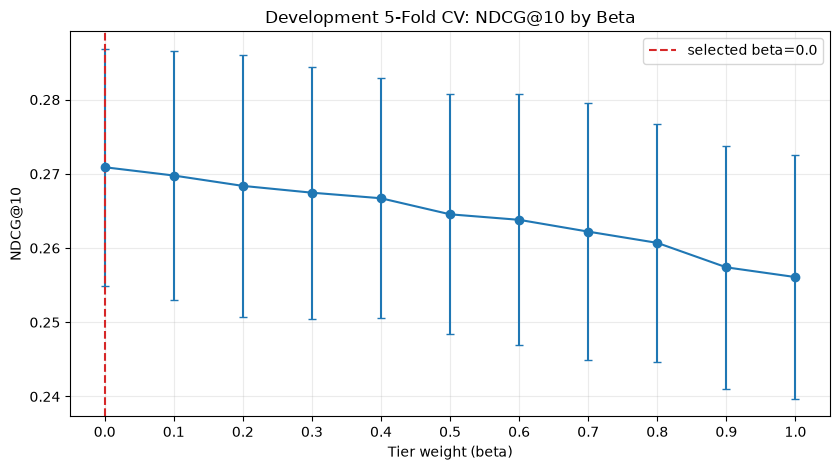

In [12]:
beta_per_query = {}
beta_fold_results = {}
beta_summary_rows = []

for beta in BETAS:
    beta = float(beta)
    detail = per_query_metrics(beta_rankings[beta], development_query_ids, relevant_by_query)
    fold_df, summary_df = fold_summary(detail)
    beta_per_query[beta] = detail
    beta_fold_results[beta] = fold_df
    mean_values, std_values = summary_df.iloc[0], summary_df.iloc[1]
    beta_summary_rows.append({
        "beta": beta,
        **{f"{metric} mean": mean_values[metric] for metric in METRIC_COLUMNS},
        **{f"{metric} std": std_values[metric] for metric in METRIC_COLUMNS},
    })

beta_results_df = pd.DataFrame(beta_summary_rows)
display(beta_results_df.round(4))

selected_beta_row = beta_results_df.sort_values(
    ["NDCG@10 mean", "Recall@10 mean", "MRR@10 mean", "beta"],
    ascending=[False, False, False, True],
).iloc[0]
selected_beta = float(selected_beta_row["beta"])
print(f"Development CV에서 선택된 Tier 후보 가중치: beta={selected_beta:.1f}")
print("이 값은 Final Holdout으로 검증된 최종 모델이 아니라 Development CV에서 선택된 후보입니다.")

plt.figure(figsize=(8.5, 4.8))
plt.errorbar(
    beta_results_df["beta"], beta_results_df["NDCG@10 mean"],
    yerr=beta_results_df["NDCG@10 std"], marker="o", capsize=3,
)
plt.axvline(selected_beta, color="tab:red", linestyle="--", label=f"selected beta={selected_beta:.1f}")
plt.xlabel("Tier weight (beta)")
plt.ylabel("NDCG@10")
plt.title("Development 5-Fold CV: NDCG@10 by Beta")
plt.xticks(BETAS)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

## 14. Baseline vs Development CV에서 선택된 Tier 후보

In [13]:
comparison_rows = []
for model_name, beta in (("Baseline (beta=0)", 0.0), (f"Tier candidate (beta={selected_beta:.1f})", selected_beta)):
    row = {"model": model_name}
    beta_row = beta_results_df.set_index("beta").loc[beta]
    for metric in METRIC_COLUMNS:
        row[f"{metric} mean"] = beta_row[f"{metric} mean"]
        if metric in ("Recall@10", "HitRate@10", "MRR@10", "NDCG@10"):
            row[f"{metric} std"] = beta_row[f"{metric} std"]
    comparison_rows.append(row)

comparison_columns = [
    "model", "Recall@10 mean", "Recall@10 std", "HitRate@10 mean", "HitRate@10 std",
    "MRR@10 mean", "MRR@10 std", "NDCG@10 mean", "NDCG@10 std",
    "Recall@20 mean", "NDCG@20 mean",
]
model_comparison_df = pd.DataFrame(comparison_rows)[comparison_columns]
display(model_comparison_df.round(4))

,model,Recall@10 mean,Recall@10 std,HitRate@10 mean,HitRate@10 std,MRR@10 mean,MRR@10 std,NDCG@10 mean,NDCG@10 std,Recall@20 mean,NDCG@20 mean
0,Baseline (beta=0),0.301,0.0289,0.5657,0.0533,0.3813,0.02,0.2709,0.016,0.35,0.2886
1,Tier candidate (beta=0.0),0.301,0.0289,0.5657,0.0533,0.3813,0.02,0.2709,0.016,0.35,0.2886


## 15. Fold별 개선 확인

In [14]:
fold_metrics = ["Recall@10", "HitRate@10", "MRR@10", "NDCG@10"]
fold_difference_df = beta_fold_results[selected_beta][["fold", *fold_metrics]].copy()
fold_difference_df[fold_metrics] = (
    beta_fold_results[selected_beta][fold_metrics] - beta_fold_results[0.0][fold_metrics]
)
display(fold_difference_df.round(4))

fold_direction_rows = []
for metric in fold_metrics:
    values = fold_difference_df[metric].to_numpy()
    fold_direction_rows.append({
        "metric": metric,
        "개선 Fold 수": int((values > 1e-12).sum()),
        "하락 Fold 수": int((values < -1e-12).sum()),
        "동일 Fold 수": int((np.abs(values) <= 1e-12).sum()),
    })
fold_direction_df = pd.DataFrame(fold_direction_rows)
display(fold_direction_df)

,fold,Recall@10,HitRate@10,MRR@10,NDCG@10
0,1,0.0,0.0,0.0,0.0
1,2,0.0,0.0,0.0,0.0
2,3,0.0,0.0,0.0,0.0
3,4,0.0,0.0,0.0,0.0
4,5,0.0,0.0,0.0,0.0


,metric,개선 Fold 수,하락 Fold 수,동일 Fold 수
0,Recall@10,0,0,5
1,HitRate@10,0,0,5
2,MRR@10,0,0,5
3,NDCG@10,0,0,5


## 16. Query 유형별 분석

In [15]:
query_group_rows = []
for query_type in ("tiered", "flat"):
    group_ids = np.array([
        int(q) for q in development_query_ids if note_types[id_to_row[int(q)]] == query_type
    ], dtype=np.int32)
    for model_name, beta in (("Baseline", 0.0), ("Tier candidate", selected_beta)):
        detail = beta_per_query[beta]
        part10 = detail[(detail["k"] == 10) & detail["query_id"].isin(group_ids)]
        query_group_rows.append({
            "query_type": query_type,
            "query_count": len(group_ids),
            "model": model_name,
            "Recall@10": part10["recall"].mean(),
            "HitRate@10": part10["hit_rate"].mean(),
            "NDCG@10": part10["ndcg"].mean(),
        })
query_group_df = pd.DataFrame(query_group_rows)
display(query_group_df.round(4))

other_types = pd.Series(note_types[development_rows]).value_counts().drop(
    labels=["tiered", "flat"], errors="ignore"
)
if len(other_types):
    print("별도 비교표에서 제외한 Development 유형:", other_types.to_dict())

,query_type,query_count,model,Recall@10,HitRate@10,NDCG@10
0,tiered,594,Baseline,0.3157,0.5808,0.2836
1,tiered,594,Tier candidate,0.3157,0.5808,0.2836
2,flat,106,Baseline,0.2188,0.4811,0.1997
3,flat,106,Tier candidate,0.2188,0.4811,0.1997


## 17. Relevant Pair 유형별 분석

In [16]:
pair_type_counts = collections.Counter()
for low, high in relevant_pairs[["pair_low", "pair_high"]].itertuples(index=False, name=None):
    type_a = note_types[id_to_row[int(low)]]
    type_b = note_types[id_to_row[int(high)]]
    if type_a == "tiered" and type_b == "tiered":
        pair_type = "tiered ↔ tiered"
    elif {type_a, type_b} == {"tiered", "flat"}:
        pair_type = "tiered ↔ flat"
    elif type_a == "flat" and type_b == "flat":
        pair_type = "flat ↔ flat"
    else:
        pair_type = "other (no_notes/invalid 포함)"
    pair_type_counts[pair_type] += 1

pair_type_order = ["tiered ↔ tiered", "tiered ↔ flat", "flat ↔ flat", "other (no_notes/invalid 포함)"]
pair_type_df = pd.DataFrame({
    "pair_type": pair_type_order,
    "pair_count": [pair_type_counts[x] for x in pair_type_order],
})
pair_type_df["ratio"] = pair_type_df["pair_count"] / pair_type_df["pair_count"].sum()
display(pair_type_df.assign(ratio=lambda x: x["ratio"].map(lambda v: f"{v:.2%}")))

,pair_type,pair_count,ratio
0,tiered ↔ tiered,7994,74.22%
1,tiered ↔ flat,2042,18.96%
2,flat ↔ flat,633,5.88%
3,other (no_notes/invalid 포함),101,0.94%


## 18. 사람이 확인할 사례

In [17]:
def notes_for_display(row, tier):
    matrix = X_by_tier[tier]
    start, end = matrix.indptr[row:row + 2]
    return ", ".join(sorted(col_to_note[int(col)] for col in matrix.indices[start:end])) or "-"

def rank_lookup(rows):
    return {int(perfume_ids[row]): rank for rank, row in enumerate(rows, start=1)}

def rank_label(rank):
    return rank if np.isfinite(rank) else f">{MAX_K}"

def case_row(query_id, relevant_id, baseline_rank, tier_rank):
    query_row, relevant_row = id_to_row[int(query_id)], id_to_row[int(relevant_id)]
    return {
        "Query perfume": perfume_names[query_row],
        "brand": perfume_brands[query_row],
        "Query Top Notes": notes_for_display(query_row, "top"),
        "Query Middle Notes": notes_for_display(query_row, "middle"),
        "Query Base Notes": notes_for_display(query_row, "base"),
        "Relevant perfume": perfume_names[relevant_row],
        "Relevant perfume Top Notes": notes_for_display(relevant_row, "top"),
        "Relevant perfume Middle Notes": notes_for_display(relevant_row, "middle"),
        "Relevant perfume Base Notes": notes_for_display(relevant_row, "base"),
        "Baseline rank": rank_label(baseline_rank),
        "Tier Model rank": rank_label(tier_rank),
    }

improved_cases, harmed_cases = [], []
for query_id in development_query_ids:
    query_id = int(query_id)
    baseline_ranks = rank_lookup(beta_rankings[0.0][query_id])
    tier_ranks = rank_lookup(beta_rankings[selected_beta][query_id])
    for relevant_id in relevant_by_query[query_id]:
        baseline_rank = baseline_ranks.get(int(relevant_id), np.inf)
        tier_rank = tier_ranks.get(int(relevant_id), np.inf)
        if baseline_rank > 10 and tier_rank <= 10:
            improved_cases.append((tier_rank - baseline_rank, query_id, int(relevant_id), baseline_rank, tier_rank))
        if baseline_rank <= 10 and tier_rank > baseline_rank:
            harmed_cases.append((tier_rank - baseline_rank, query_id, int(relevant_id), baseline_rank, tier_rank))

improved_cases.sort(key=lambda x: (x[0], x[1], x[2]))
harmed_cases.sort(key=lambda x: (-x[0], x[1], x[2]))

display(Markdown("### Baseline TOP 10에는 없었지만 Tier 후보 TOP 10에서 찾은 사례 (최대 10개)"))
if improved_cases:
    display(pd.DataFrame([case_row(*case[1:]) for case in improved_cases[:10]]))
else:
    print("해당 사례가 없습니다.")

display(Markdown("### Baseline은 찾았지만 Tier 후보에서 순위가 하락한 사례 (최대 10개)"))
if harmed_cases:
    display(pd.DataFrame([case_row(*case[1:]) for case in harmed_cases[:10]]))
else:
    print("해당 사례가 없습니다.")

### Baseline TOP 10에는 없었지만 Tier 후보 TOP 10에서 찾은 사례 (최대 10개)

해당 사례가 없습니다.


### Baseline은 찾았지만 Tier 후보에서 순위가 하락한 사례 (최대 10개)

해당 사례가 없습니다.


## 19. Paired Bootstrap: 개선 방향의 안정성

In [18]:
def development_metric_vector(beta, metric_name, k=10):
    detail = beta_per_query[float(beta)]
    lookup = detail[detail["k"] == k].set_index("query_id")[metric_name]
    return np.array([lookup.loc[int(q)] for q in development_query_ids], dtype=float)

bootstrap_rng = np.random.default_rng(SEED)
bootstrap_rows = []
for display_name, metric_name in (("Recall@10", "recall"), ("NDCG@10", "ndcg")):
    differences = (
        development_metric_vector(selected_beta, metric_name)
        - development_metric_vector(0.0, metric_name)
    )
    indices = bootstrap_rng.integers(
        0, len(differences), size=(BOOTSTRAP_RESAMPLES, len(differences))
    )
    bootstrap_means = differences[indices].mean(axis=1)
    lower, upper = np.quantile(bootstrap_means, [0.025, 0.975])
    includes_zero = bool(lower <= 0 <= upper)
    bootstrap_rows.append({
        "metric": display_name,
        "mean_difference": differences.mean(),
        "ci_2.5%": lower,
        "ci_97.5%": upper,
        "CI_includes_zero": includes_zero,
        "improvement_direction_stability": (
            "개선 방향이 안정적" if lower > 0
            else "하락 방향이 안정적" if upper < 0
            else "CI가 0을 포함해 방향이 안정적이지 않음"
        ),
    })
bootstrap_df = pd.DataFrame(bootstrap_rows)
display(bootstrap_df.round(4))

,metric,mean_difference,ci_2.5%,ci_97.5%,CI_includes_zero,improvement_direction_stability
0,Recall@10,0.0,0.0,0.0,True,CI가 0을 포함해 방향이 안정적이지 않음
1,NDCG@10,0.0,0.0,0.0,True,CI가 0을 포함해 방향이 안정적이지 않음


## 20. 결과 해석과 최종 요약

In [19]:
baseline_row = beta_results_df.set_index("beta").loc[0.0]
tier_row = beta_results_df.set_index("beta").loc[selected_beta]
recall_change = tier_row["Recall@10 mean"] - baseline_row["Recall@10 mean"]
hit_change = tier_row["HitRate@10 mean"] - baseline_row["HitRate@10 mean"]
ndcg_change = tier_row["NDCG@10 mean"] - baseline_row["NDCG@10 mean"]

recall_improved_folds = int((fold_difference_df["Recall@10"] > 0).sum())
ndcg_improved_folds = int((fold_difference_df["NDCG@10"] > 0).sum())
bootstrap_lookup = bootstrap_df.set_index("metric")
recall_ci = bootstrap_lookup.loc["Recall@10"]
ndcg_ci = bootstrap_lookup.loc["NDCG@10"]

case_a = (
    ndcg_change > 0 and recall_change > 0
    and ndcg_improved_folds >= 3 and recall_improved_folds >= 3
    and ndcg_ci["ci_2.5%"] > 0 and recall_ci["ci_2.5%"] > 0
)
case_b = abs(ndcg_change) < 0.001 and abs(recall_change) < 0.001
case_c = ndcg_change < 0 and recall_change <= 0

if case_a:
    conclusion = "Note 위치 정보가 기존 union Note 표현에 추가적인 추천 신호를 제공한다."
    keep_candidate = "예 — Development CV 후보로 유지 (Final Holdout 평가는 아직 수행하지 않음)"
elif case_b:
    conclusion = "Note 존재 여부만으로 대부분의 정보가 설명되며, Tier 위치의 추가 정보량은 제한적이다."
    keep_candidate = "보류 — 효과가 거의 없어 후속 검증의 우선순위가 낮음"
elif case_c:
    conclusion = "정확한 Tier 일치 조건이 향 유사성을 과도하게 제한할 수 있어 강한 위치 구분은 적절하지 않을 수 있다."
    keep_candidate = "아니오 — 현재 형태의 Tier exact-match 후보는 유지하지 않음"
else:
    conclusion = "지표와 Fold·Bootstrap 방향이 혼재하므로 Tier 정보의 추가 효과를 단정하기 어렵다."
    keep_candidate = "보류 — Development 안에서 효과가 일관되지 않음"

all_structure = note_structure_df[note_structure_df["dataset"] == "전체 향수"].set_index("note_type")
tiered_ratio = all_structure.loc["tiered", "ratio"]
flat_ratio = all_structure.loc["flat", "ratio"]
tier_pair_ratio = pair_type_df.set_index("pair_type").loc["tiered ↔ tiered", "ratio"]

diagnostic_lookup = diagnostic_results_df.set_index("model")
union_diag = diagnostic_lookup.loc["Union IDF Note"]
tier_diag = diagnostic_lookup.loc["Tier IDF Note"]
tier_match_lookup = tier_match_df.set_index("category")
same_tier_ratio = tier_match_lookup.loc["같은 Tier 일치가 있는 공통 Note", "ratio"]
different_tier_ratio = tier_match_lookup.loc["서로 다른 Tier에서만 나타나는 공통 Note", "ratio"]

effect_size = (
    f"Recall@10 {recall_change:+.4f}, NDCG@10 {ndcg_change:+.4f}; {conclusion}"
)

summary_markdown = f"""
## Note Tier 데이터

- Tiered 향수 비율: **{tiered_ratio:.2%}**
- Flat 향수 비율: **{flat_ratio:.2%}**
- Tier 정보 사용 가능한 Relevant Pair 비율: **{tier_pair_ratio:.2%}** (`tiered ↔ tiered`)

## Diagnostic Experiment

Union Note:
- Recall@10: **{union_diag['Recall@10 mean']:.4f} ± {union_diag['Recall@10 std']:.4f}**
- NDCG@10: **{union_diag['NDCG@10 mean']:.4f} ± {union_diag['NDCG@10 std']:.4f}**

Tier Note:
- Recall@10: **{tier_diag['Recall@10 mean']:.4f} ± {tier_diag['Recall@10 std']:.4f}**
- NDCG@10: **{tier_diag['NDCG@10 mean']:.4f} ± {tier_diag['NDCG@10 std']:.4f}**

## Tier 위치 관계

- 같은 Tier 공통 Note 비율: **{same_tier_ratio:.2%}**
- 다른 Tier에서만 나타나는 공통 Note 비율: **{different_tier_ratio:.2%}**

## Beta 탐색

- 선택된 beta: **{selected_beta:.1f}** (Development CV에서 선택된 Tier 후보 가중치)
- Baseline beta=0 NDCG@10: **{baseline_row['NDCG@10 mean']:.4f}**
- 선택 beta NDCG@10: **{tier_row['NDCG@10 mean']:.4f}**
- Recall@10 변화: **{recall_change:+.4f}**
- HitRate@10 변화: **{hit_change:+.4f}**

## Cross Validation

- 개선 Fold 수: **Recall@10 {recall_improved_folds}/5, NDCG@10 {ndcg_improved_folds}/5**
- Recall@10 평균 변화: **{recall_change:+.4f}**
- NDCG@10 평균 변화: **{ndcg_change:+.4f}**

## Bootstrap

- Recall@10 CI: **[{recall_ci['ci_2.5%']:.4f}, {recall_ci['ci_97.5%']:.4f}]** (0 포함: {recall_ci['CI_includes_zero']})
- NDCG@10 CI: **[{ndcg_ci['ci_2.5%']:.4f}, {ndcg_ci['ci_97.5%']:.4f}]** (0 포함: {ndcg_ci['CI_includes_zero']})
- 위 구간은 가설검정 표현이 아니라 **개선 방향의 안정성**을 확인하기 위한 paired bootstrap 결과이다.

## 현재 판단

- Tier 정보를 최종 feature 후보로 유지할지: **{keep_candidate}**
- Tier 정보의 효과 크기: **{effect_size}**
- Flat perfume fallback 방식: **Union IDF Note Similarity**
- 다음 Ablation 후보: **선택 beta 주변의 더 세밀한 가중치 또는 서로 다른 Tier의 부분 일치를 허용하는 완화 방식** (이번 Notebook에서는 수행하지 않음)

### 해석

{conclusion}

Final Holdout 300개는 끝까지 평가하지 않았다. 이 결론은 Development 700개 내부의 5-Fold CV와 paired bootstrap에 한정된다.
"""
display(Markdown(summary_markdown))
print("Final Holdout 평가 query 수: 0")


## Note Tier 데이터

- Tiered 향수 비율: **70.62%**
- Flat 향수 비율: **27.46%**
- Tier 정보 사용 가능한 Relevant Pair 비율: **74.22%** (`tiered ↔ tiered`)

## Diagnostic Experiment

Union Note:
- Recall@10: **0.2972 ± 0.0294**
- NDCG@10: **0.2659 ± 0.0213**

Tier Note:
- Recall@10: **0.2906 ± 0.0224**
- NDCG@10: **0.2569 ± 0.0124**

## Tier 위치 관계

- 같은 Tier 공통 Note 비율: **88.14%**
- 다른 Tier에서만 나타나는 공통 Note 비율: **11.86%**

## Beta 탐색

- 선택된 beta: **0.0** (Development CV에서 선택된 Tier 후보 가중치)
- Baseline beta=0 NDCG@10: **0.2709**
- 선택 beta NDCG@10: **0.2709**
- Recall@10 변화: **+0.0000**
- HitRate@10 변화: **+0.0000**

## Cross Validation

- 개선 Fold 수: **Recall@10 0/5, NDCG@10 0/5**
- Recall@10 평균 변화: **+0.0000**
- NDCG@10 평균 변화: **+0.0000**

## Bootstrap

- Recall@10 CI: **[0.0000, 0.0000]** (0 포함: True)
- NDCG@10 CI: **[0.0000, 0.0000]** (0 포함: True)
- 위 구간은 가설검정 표현이 아니라 **개선 방향의 안정성**을 확인하기 위한 paired bootstrap 결과이다.

## 현재 판단

- Tier 정보를 최종 feature 후보로 유지할지: **보류 — 효과가 거의 없어 후속 검증의 우선순위가 낮음**
- Tier 정보의 효과 크기: **Recall@10 +0.0000, NDCG@10 +0.0000; Note 존재 여부만으로 대부분의 정보가 설명되며, Tier 위치의 추가 정보량은 제한적이다.**
- Flat perfume fallback 방식: **Union IDF Note Similarity**
- 다음 Ablation 후보: **선택 beta 주변의 더 세밀한 가중치 또는 서로 다른 Tier의 부분 일치를 허용하는 완화 방식** (이번 Notebook에서는 수행하지 않음)

### 해석

Note 존재 여부만으로 대부분의 정보가 설명되며, Tier 위치의 추가 정보량은 제한적이다.

Final Holdout 300개는 끝까지 평가하지 않았다. 이 결론은 Development 700개 내부의 5-Fold CV와 paired bootstrap에 한정된다.


Final Holdout 평가 query 수: 0


## Note Tier 데이터

- Tiered 향수 비율: **70.62%**
- Flat 향수 비율: **27.46%**
- Tier 정보 사용 가능한 Relevant Pair 비율: **74.22%** (`tiered ↔ tiered`)

## Diagnostic Experiment

Union Note:
- Recall@10: **0.2972 ± 0.0294**
- NDCG@10: **0.2659 ± 0.0213**

Tier Note:
- Recall@10: **0.2906 ± 0.0224**
- NDCG@10: **0.2569 ± 0.0124**

## Tier 위치 관계

- 같은 Tier 공통 Note 비율: **88.14%**
- 다른 Tier에서만 나타나는 공통 Note 비율: **11.86%**

## Beta 탐색

- 선택된 beta: **0.0** (Development CV에서 선택된 Tier 후보 가중치)
- Baseline beta=0 NDCG@10: **0.2709**
- 선택 beta NDCG@10: **0.2709**
- Recall@10 변화: **+0.0000**
- HitRate@10 변화: **+0.0000**

## Cross Validation

- 개선 Fold 수: **Recall@10 0/5, NDCG@10 0/5**
- Recall@10 평균 변화: **+0.0000**
- NDCG@10 평균 변화: **+0.0000**

## Bootstrap

- Recall@10 CI: **[0.0000, 0.0000]** (0 포함: True)
- NDCG@10 CI: **[0.0000, 0.0000]** (0 포함: True)
- 위 구간은 가설검정 표현이 아니라 **개선 방향의 안정성**을 확인하기 위한 paired bootstrap 결과이다.

## 현재 판단

- Tier 정보를 최종 feature 후보로 유지할지: **보류 — 효과가 거의 없어 후속 검증의 우선순위가 낮음**
- Tier 정보의 효과 크기: **Recall@10 +0.0000, NDCG@10 +0.0000; Note 존재 여부만으로 대부분의 정보가 설명되며, Tier 위치의 추가 정보량은 제한적이다.**
- Flat perfume fallback 방식: **Union IDF Note Similarity**
- 다음 Ablation 후보: **선택 beta 주변의 더 세밀한 가중치 또는 서로 다른 Tier의 부분 일치를 허용하는 완화 방식** (이번 Notebook에서는 수행하지 않음)

### 해석

Note 존재 여부만으로 대부분의 정보가 설명되며, Tier 위치의 추가 정보량은 제한적이다.

Final Holdout 300개는 끝까지 평가하지 않았다. 이 결론은 Development 700개 내부의 5-Fold CV와 paired bootstrap에 한정된다.